# Finance RAG — FinanceBench (ICAIF-24)

Retrieval + optional rerank + generation для финансовых вопросов.

Данные (в `data/`):
- `corpus.jsonl` — `_id`, `title`, `text`
- `queries.jsonl` — `_id`, `text`
- `FinanceBench_qrels.tsv` — `query_id`, `corpus_id`, `score`

Источник: [ICAIF-24 Finance RAG Challenge](https://www.kaggle.com/competitions/icaif-24-finance-rag-challenge).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import set_seed, RANDOM_STATE, write_jsonl
from src.data_loader import load_financebench, doc_text
from src.pipeline import RetrievalPipeline
from src.evaluate import evaluate_retrieval, print_metrics
from src.generate import generate_answer, build_context

set_seed(RANDOM_STATE)
DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
print('ROOT =', ROOT)


ROOT = d:\Projects_ML\FinanceRAG\finance_rag


## 1. Load data

In [2]:
corpus, queries, qrels = load_financebench(DATA_DIR)

print(f'corpus:  {len(corpus)} docs')
print(f'queries: {len(queries)}')
print(f'qrels:   {len(qrels)} queries with relevance labels')

# overlap check
q_in_qrels = sum(1 for q in queries if q in qrels)
print(f'queries ∩ qrels: {q_in_qrels}')

# sample
qid0 = next(iter(queries))
print('\nSample query:', queries[qid0][:200])
did0 = next(iter(corpus))
print('Sample doc:', doc_text(corpus[did0])[:300])


corpus:  180 docs
queries: 150
qrels:   45 queries with relevance labels
queries ∩ qrels: 45

Sample query: What is the FY2019 - FY2020 total revenue growth rate for Block (formerly known as Square)? Answer in units of percents and round to one decimal place. Approach the question asked by assuming the stan
Sample doc: PEPSICO_2022_10K
6) Africa, Middle East and South Asia (AMESA), which includes all of our beverage and convenient food businesses in
Africa, the Middle East and South Asia; and
7) Asia Pacific, Australia and New Zealand and China Region (APAC), which includes all of our beverage and convenient
food 


## 2. Build indexes

Dense model по умолчанию — `all-MiniLM-L6-v2` (быстрый baseline).
Для лучшего качества на finance можно заменить на `BAAI/bge-base-en-v1.5`.

In [ ]:
# use_reranker=True — дольше, но обычно поднимает NDCG
pipe = RetrievalPipeline(
    corpus,
    dense_model='sentence-transformers/all-MiniLM-L6-v2',
    use_reranker=True,
)
print('index ready, backend dense:', pipe.dense._backend)


## 3. Retrieval comparison

Считаем NDCG@10 / Recall@10 / MRR@10 для:
- BM25
- Dense
- Hybrid (RRF)
- Hybrid + cross-encoder rerank


In [4]:
# на полном наборе CE rerank может быть медленным —
# для быстрого прогона ограничим число запросов
MAX_QUERIES = None  # поставь 30 для smoke-test

eval_queries = queries
if MAX_QUERIES is not None:
    eval_queries = dict(list(queries.items())[:MAX_QUERIES])

modes = {
    'bm25': dict(mode='bm25', rerank=False),
    'dense': dict(mode='dense', rerank=False),
    'hybrid': dict(mode='hybrid', rerank=False),
    'hybrid+rerank': dict(mode='hybrid', rerank=True),
}

all_results = {}
metrics_table = {}

for name, cfg in modes.items():
    print(f'\n=== {name} ===')
    # временно отключаем reranker если не нужен
    had_reranker = pipe.reranker
    if not cfg['rerank']:
        pipe.reranker = None
    else:
        pipe.reranker = had_reranker if had_reranker is not None else pipe.reranker

    res = pipe.retrieve_many(
        eval_queries,
        mode=cfg['mode'],
        top_k=50,
        rerank_top_k=10,
        fusion='rrf',
    )
    # вернуть reranker обратно
    pipe.reranker = had_reranker

    all_results[name] = res
    # qrels только по пересечению
    qrels_sub = {q: qrels[q] for q in res if q in qrels}
    m = evaluate_retrieval(res, qrels_sub, k_values=[5, 10])
    metrics_table[name] = m
    print_metrics(name, m)



=== bm25 ===
  retrieve 20/150
  retrieve 40/150
  retrieve 60/150
  retrieve 80/150
  retrieve 100/150
  retrieve 120/150
  retrieve 140/150
bm25:
  ndcg@5: 0.2010
  recall@5: 0.2444
  mrr@5: 0.2026
  ndcg@10: 0.2357
  recall@10: 0.3444
  mrr@10: 0.2187

=== dense ===
  retrieve 20/150
  retrieve 40/150
  retrieve 60/150
  retrieve 80/150
  retrieve 100/150
  retrieve 120/150
  retrieve 140/150
dense:
  ndcg@5: 0.7193
  recall@5: 0.9222
  mrr@5: 0.6785
  ndcg@10: 0.7424
  recall@10: 0.9889
  mrr@10: 0.6841

=== hybrid ===
  retrieve 20/150
  retrieve 40/150
  retrieve 60/150
  retrieve 80/150
  retrieve 100/150
  retrieve 120/150
  retrieve 140/150
hybrid:
  ndcg@5: 0.4642
  recall@5: 0.6222
  mrr@5: 0.4233
  ndcg@10: 0.4888
  recall@10: 0.6889
  mrr@10: 0.4344

=== hybrid+rerank ===
  retrieve 20/150
  retrieve 40/150
  retrieve 60/150
  retrieve 80/150
  retrieve 100/150
  retrieve 120/150
  retrieve 140/150
hybrid+rerank:
  ndcg@5: 0.6859
  recall@5: 0.8444
  mrr@5: 0.6548
  ndcg@

               ndcg@5  recall@5   mrr@5  ndcg@10  recall@10  mrr@10
dense          0.7193    0.9222  0.6785   0.7424     0.9889  0.6841
hybrid+rerank  0.6859    0.8444  0.6548   0.7011     0.8889  0.6570
hybrid         0.4642    0.6222  0.4233   0.4888     0.6889  0.4344
bm25           0.2010    0.2444  0.2026   0.2357     0.3444  0.2187


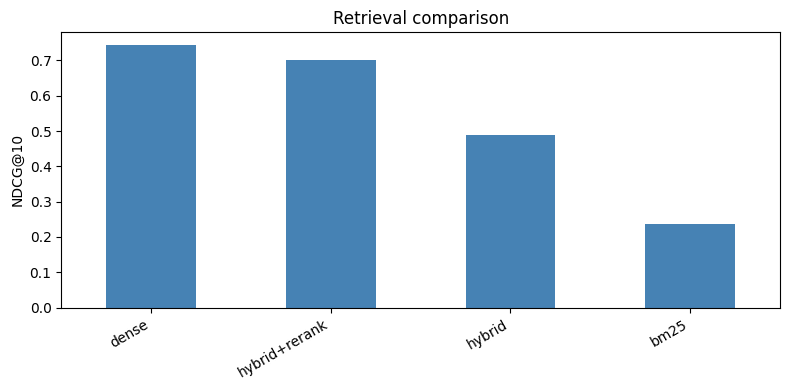

In [5]:
df_m = pd.DataFrame(metrics_table).T.round(4)
df_m = df_m.sort_values('ndcg@10', ascending=False)
print(df_m.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
df_m['ndcg@10'].plot.bar(ax=ax, color='steelblue')
ax.set_ylabel('NDCG@10')
ax.set_title('Retrieval comparison')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 4. Generation (few examples)

In [7]:
# берём лучший метод по ndcg@10
best_method = df_m.index[0]
print('Best retrieval:', best_method)

# 3 запроса из qrels
sample_qids = [q for q in eval_queries if q in qrels][:3]

gen_rows = []
for qid in sample_qids:
    qtext = queries[qid]
    hits = all_results[best_method][qid]
    print('\n' + '=' * 60)
    print('Q:', qtext)
    print('Top-3 docs:', [h[0] for h in hits[:3]])

    backend='ollama'
    model_name='llama3.1'

    out = generate_answer(qtext, hits, corpus, backend=backend, model=model_name, max_passages=4)
    print('Backend:', out['backend'])
    print('A:', out['answer'][:800])
    print('Sources:', out['source_ids'])
    gen_rows.append({
        'query_id': qid,
        'query': qtext,
        'answer': out['answer'],
        'sources': out['source_ids'],
        'backend': out['backend'],
    })


Best retrieval: dense

Q: How does Boeing's effective tax rate in FY2022 compare to FY2021?
Top-3 docs: ['dd2acffb6', 'dd2acf638', 'dd2acf0f2']
Backend: ollama:llama3.1
A: To determine the effective tax rate for both years, we need to calculate the income tax (expense)/benefit as a percentage of the loss before income taxes.

For FY2022:
Loss before income taxes = $5,022 million
Income tax (expense)/benefit = ($31) million (note: this is a negative number, indicating an income tax benefit)
Effective tax rate in FY2022 = (($31) / $5,022) * 100% ≈ -0.62%

For FY2021:
Loss before income taxes = $5,033 million
Income tax (expense)/benefit = $743 million
Effective tax rate in FY2021 = ($743 / $5,033) * 100% ≈ 14.76%

Comparing the two years, Boeing's effective tax rate in FY2022 is approximately -0.62%, which is significantly lower than the 14.76% effective tax rate in FY2021.

Note: The negative effective tax rate in FY2022 indicates that Boeing received a tax b
Sources: ['dd2acffb6', 'dd2

In [ ]:
# сохранить результаты
out_path = RESULTS_DIR / 'generation_samples.jsonl'
write_jsonl(out_path, gen_rows)
print('saved', out_path)

# retrieval runs
for name, res in all_results.items():
    rows = []
    for qid, hits in res.items():
        for rank, (did, score) in enumerate(hits, start=1):
            rows.append({'query_id': qid, 'corpus_id': did, 'score': score, 'rank': rank})
    pd.DataFrame(rows).to_csv(RESULTS_DIR / f'retrieval_{name}.csv', index=False)
print('retrieval csv saved in', RESULTS_DIR)


## 5. Выводы

- Hybrid (RRF) обычно стабильнее pure dense/BM25 на финансовых запросах: BM25 ловит тикеры и точные термины, dense — перефразы.
- Cross-encoder rerank дороже по CPU/GPU, но часто даёт лучший NDCG@10 на top-10.
- Генерация без LLM (extractive) годится только для отладки пайплайна; для нормальных ответов нужен Groq или Ollama.
- RAGAS не включён по умолчанию — тяжёлые зависимости и LLM-as-judge. При необходимости: `pip install ragas` и прогнать faithfulness / answer_relevancy на `gen_rows`.

### Что улучшить
- Более сильный embedding (bge, e5, finance-domain)
- Query rewriting под 10-K jargon
- Section-aware chunking
- Кэш FAISS-индекса между сессиями